In [59]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [60]:
r = np.full((20, 1000),fill_value=np.nan)

In [61]:
df = pd.read_csv('ratings_long.csv')

In [63]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [65]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

## Veri 
 - Veriyi incelediğimizde 20 user, %17.9 ratinglenmiş film, 1-5 arası değerlendirme puanı ve 
%82.1 loss ve gradient hesabında etkileri olmayan filmlerimiz var. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ratings_long.csv')
df.head()

,userId,movieId,rating
0,0,16,5
1,0,72,5
2,0,86,5
3,0,259,1
4,0,319,4


In [3]:
r = np.full((20, 1000), np.nan)
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

In [4]:
dolu = [(i, j) for i in range(20) for j in range(1000) if not np.isnan(r[i][j])]
print("Dolu hücre sayısı:", len(dolu))   

Dolu hücre sayısı: 200


In [5]:
np.random.seed(42)
K = 4
u = np.random.random((20, K))
v = np.random.random((K, 1000))
print("u şekli:", u.shape, "| v şekli:", v.shape)

u şekli: (20, 4) | v şekli: (4, 1000)


In [6]:
def loss(u, v, lam):
    hata_toplami = 0.0
    for (i, j) in dolu:
        tahmin = np.dot(u[i], v[:, j])
        hata_toplami += (r[i][j] - tahmin) ** 2
    mse = hata_toplami / len(dolu)               
    reg = lam * (np.sum(u**2) + np.sum(v**2))
    return mse + reg

In [7]:
np.random.seed(42)
u = np.random.random((20, 4))       
v = np.random.random((4, 1000))

lr, lam, epochs = 0.1, 0.005, 2000
N = len(dolu)
loss_gecmisi = []

for epoch in range(epochs):
    grad_u = np.zeros_like(u)
    grad_v = np.zeros_like(v)

    for (i, j) in dolu:
        e = r[i][j] - np.dot(u[i], v[:, j])
        grad_u[i]   += -2 * e * v[:, j]
        grad_v[:, j] += -2 * e * u[i]

    grad_u /= N
    grad_v /= N
    grad_u += 2 * lam * u
    grad_v += 2 * lam * v

    gnorm = np.sqrt(np.sum(grad_u**2) + np.sum(grad_v**2))

    u -= lr * grad_u
    v -= lr * grad_v
    loss_gecmisi.append(loss(u, v, lam))

    if epoch % 100 == 0:
        print(f"epoch {epoch}  gradient_norm={gnorm:.4f}  loss={loss_gecmisi[-1]:.4f}")

    if gnorm < 0.01:
        print(f"--- early stop epoch {epoch} ---")
        break

print("Son loss:", round(loss_gecmisi[-1], 4))

epoch 0  gradient_norm=1.1428  loss=13.2478
epoch 100  gradient_norm=0.4829  loss=7.5905
epoch 200  gradient_norm=0.3279  loss=6.0606
epoch 300  gradient_norm=0.2695  loss=5.1887
epoch 400  gradient_norm=0.2360  loss=4.5556
epoch 500  gradient_norm=0.2109  loss=4.0584
epoch 600  gradient_norm=0.1897  loss=3.6583
epoch 700  gradient_norm=0.1711  loss=3.3337
epoch 800  gradient_norm=0.1544  loss=3.0695
epoch 900  gradient_norm=0.1395  loss=2.8542
epoch 1000  gradient_norm=0.1260  loss=2.6785
epoch 1100  gradient_norm=0.1139  loss=2.5349
epoch 1200  gradient_norm=0.1030  loss=2.4177
epoch 1300  gradient_norm=0.0931  loss=2.3217
epoch 1400  gradient_norm=0.0843  loss=2.2432
epoch 1500  gradient_norm=0.0763  loss=2.1789
epoch 1600  gradient_norm=0.0691  loss=2.1262
epoch 1700  gradient_norm=0.0626  loss=2.0830
epoch 1800  gradient_norm=0.0567  loss=2.0476
epoch 1900  gradient_norm=0.0514  loss=2.0184
Son loss: 1.9947


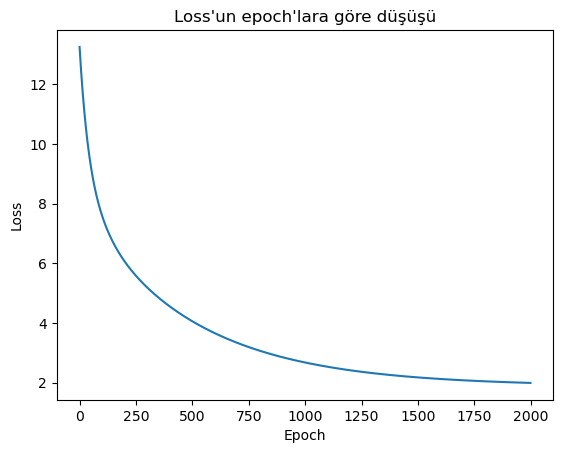

In [9]:
plt.plot(loss_gecmisi)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss'un epoch'lara göre düşüşü")
plt.show()

In [10]:
R_pred = u @ v
print("Tahmin matrisi şekli:", R_pred.shape)
print("Tahmin aralığı: min=%.2f  max=%.2f" % (R_pred.min(), R_pred.max()))
R_pred_kirpik = np.clip(R_pred, 1, 5)

Tahmin matrisi şekli: (20, 1000)
Tahmin aralığı: min=0.05  max=6.31


In [11]:
kullanici = 0
puanlanan = set(df[df.userId == kullanici].movieId)
tahminler = [(film, R_pred[kullanici][film])
             for film in range(1000) if film not in puanlanan]
tahminler.sort(key=lambda x: -x[1])

print(f"Kullanıcı {kullanici} için ilk 5 film önerisi:")
for film, skor in tahminler[:5]:
    print(f"  film {film}: tahmini puan {skor:.2f}")

Kullanıcı 0 için ilk 5 film önerisi:
  film 784: tahmini puan 5.36
  film 508: tahmini puan 4.76
  film 22: tahmini puan 4.67
  film 744: tahmini puan 4.65
  film 276: tahmini puan 4.44


# Train test ayrımı 
Burada 80/20 bölmedim hocam çünkü bazı filmlerde tek rating var. 
rating sayısı>1 olanları aldım test için çünkü tek puanlı bir filmin o tek puanını test'e ayırırsak film train'de hiç kalmaz, vektörü eğitilemez ve tahmini anlamsız olur

In [14]:
np.random.seed(42)
test_idx = [g.sample(1, random_state=42).index[0]
            for _, g in df.groupby('movieId') if len(g) >= 2]
test_df = df.loc[test_idx]
train_df = df.drop(test_idx)
print("Train:", len(train_df), "| Test:", len(test_df))

r_tr = np.full((20, 1000), np.nan)
for rec in train_df.itertuples():
    r_tr[rec.userId][rec.movieId] = rec.rating
dolu_tr = [(i, j) for i in range(20) for j in range(1000) if not np.isnan(r_tr[i][j])]

np.random.seed(42)
u_tr = np.random.random((20, 4))
v_tr = np.random.random((4, 1000))
lr, lam, epochs = 0.1, 0.005, 2000
N_tr = len(dolu_tr)

for epoch in range(epochs):
    gu = np.zeros_like(u_tr); gv = np.zeros_like(v_tr)
    for (i, j) in dolu_tr:
        e = r_tr[i][j] - np.dot(u_tr[i], v_tr[:, j])
        gu[i] += -2 * e * v_tr[:, j]
        gv[:, j] += -2 * e * u_tr[i]
    gu /= N_tr; gv /= N_tr
    gu += 2 * lam * u_tr; gv += 2 * lam * v_tr
    gnorm = np.sqrt(np.sum(gu**2) + np.sum(gv**2))
    u_tr -= lr * gu; v_tr -= lr * gv
    if gnorm < 0.01:
        break

Train: 181 | Test: 19


In [15]:
def rmse(pairs):
    sq = sum((rat - np.dot(u_tr[i], v_tr[:, j]))**2 for i, j, rat in pairs)
    return np.sqrt(sq / len(pairs))

train_pairs = [(i, j, r_tr[i][j]) for (i, j) in dolu_tr]
test_pairs = [(rec.userId, rec.movieId, rec.rating) for rec in test_df.itertuples()]
ort = train_df.rating.mean()
base = np.sqrt(sum((rat - ort)**2 for _, _, rat in test_pairs) / len(test_pairs))

print("Train RMSE   :", round(rmse(train_pairs), 3))
print("Test RMSE    :", round(rmse(test_pairs), 3))
print("Baseline RMSE:", round(base, 3))

Train RMSE   : 0.301
Test RMSE    : 1.96
Baseline RMSE: 1.428


**Değerlendirme:** Train RMSE 0.30 ile model eğitim verisini iyi öğreniyor ama Test RMSE 1.96 ile baseline'ı (1.43) geçemiyor; çünkü stratified split'te yalnızca ≥2 puanlı 19 film test'e ayrılabildi (160 film tek puanlama olduğundan) ve veri bu kadar seyrekken model yeterince örüntü öğrenemiyor diye düşünüyorum. 